# Vícios do dataset `og_qa_v0` — demonstração visual

As 2546 questões de `datasets/og_qa_v0/test.json` foram geradas com ChatGPT e carregam
**vícios típicos** que tornam muitas questões respondíveis **sem nenhum conhecimento de
óleo e gás**. Este notebook demonstra cada vício com **um gráfico** e mostra
**questões reais** em que dá para chutar a resposta só olhando a "cara" das alternativas.

| # | Vício | Resumo |
|---|---|---|
| 1 | **Posição da resposta enviesada** | ~85% das respostas estão em B ou C; D quase não é gabarito |
| 2 | **"Maior alternativa = correta"** | a correta costuma ser bem mais longa/detalhada que os distratores |
| 3 | **Enunciado definicional (decoreba)** | ~80% dos enunciados terminam em "`:`" — pura definição, sem cenário |
| 4 | **Distratores-lixo** | distratores curtíssimos e implausíveis (ex.: *"Vagas de hotel"*) |

Fechamos com um teste de **chute cego**: estratégias que ignoram o conteúdo da questão
e ainda assim acertam muito acima dos 25% esperados ao acaso.

In [1]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "datasets/og_qa_v0/test.json"
questions = json.load(open(DATA_PATH, encoding="utf-8"))
N = len(questions)

# ---- helpers (auto-contidos, mesmo esquema do og_qa_v0) ----
WORD_RE = re.compile(r"[A-Za-zÀ-ÿ0-9]+")
def n_words(s):        return len(WORD_RE.findall(s or ""))
def correct_index(q):  return q["choices"]["label"].index(q["answerKey"])
def correct_text(q):   return q["choices"]["text"][correct_index(q)]
def distractors(q):
    ci = correct_index(q)
    return [t for i, t in enumerate(q["choices"]["text"]) if i != ci]

print(f"{N} questões carregadas")

2546 questões carregadas


## Vício 1 — Posição da resposta enviesada

Num dataset bem construído, o gabarito deveria se distribuir ~uniformemente entre
A, B, C e D (25% cada). Aqui o ChatGPT concentrou o gabarito em **B e C**:
quem **sempre chuta B** já acerta ~43% — quase o dobro do acaso — e **D é gabarito
em só ~2%** das questões (ou seja, dá para *descartar* D quase de graça).

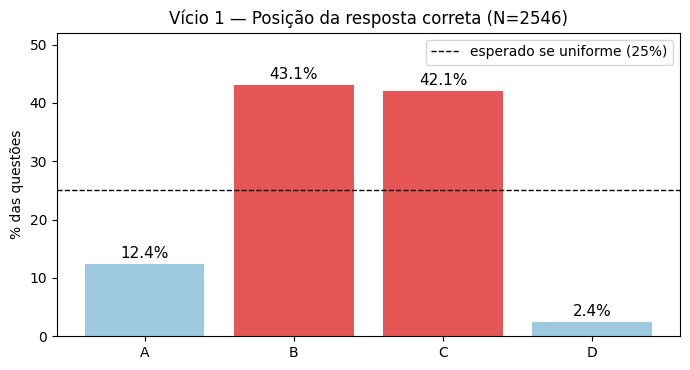

B ou C concentram 85.2% dos gabaritos; D tem só 2.4%.


In [2]:
key_counts = pd.Series([q["answerKey"] for q in questions]).value_counts().reindex(list("ABCD")).fillna(0).astype(int)
pct = key_counts / N * 100

fig, ax = plt.subplots(figsize=(7, 3.8))
colors = ["#9ecae1", "#e45756", "#e45756", "#9ecae1"]
bars = ax.bar(pct.index, pct.values, color=colors)
ax.axhline(25, color="k", ls="--", lw=1, label="esperado se uniforme (25%)")
for b, v in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, 52)
ax.set_ylabel("% das questões")
ax.set_title(f"Vício 1 — Posição da resposta correta (N={N})")
ax.legend()
plt.tight_layout(); plt.show()

print(f"B ou C concentram {pct['B'] + pct['C']:.1f}% dos gabaritos; D tem só {pct['D']:.1f}%.")

## Vício 2 — "A alternativa mais longa é a correta"

Vício clássico de questão gerada por LLM: a alternativa correta é escrita com mais
cuidado/detalhe, e os distratores são jogados. O histograma abaixo mostra a razão
**tamanho da correta ÷ tamanho médio dos distratores** (em palavras). Se as questões
fossem equilibradas, a distribuição ficaria concentrada em torno de **1,0**.

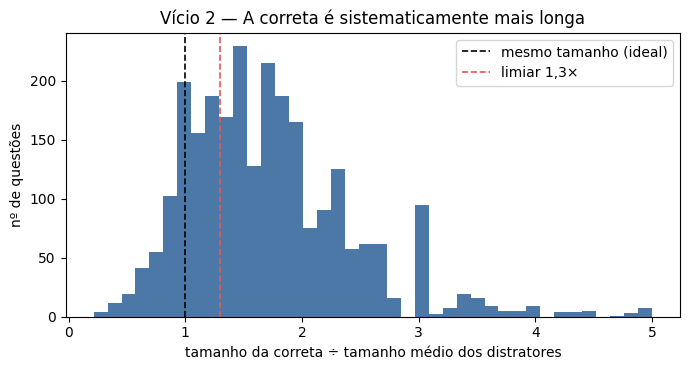

Correta >1,3× mais longa que os distratores: 69.6%
A alternativa MAIS LONGA é a correta em 72.1% das questões (esperado: ~25%).


In [3]:
cor_w = np.array([n_words(correct_text(q)) for q in questions])
dis_w = np.array([np.mean([n_words(d) for d in distractors(q)]) for q in questions])
ratio = cor_w / np.maximum(dis_w, 1e-6)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(np.clip(ratio, 0, 5), bins=40, color="#4c78a8")
ax.axvline(1.0, color="k",       ls="--", lw=1.2, label="mesmo tamanho (ideal)")
ax.axvline(1.3, color="#e45756", ls="--", lw=1.2, label="limiar 1,3×")
ax.set_xlabel("tamanho da correta ÷ tamanho médio dos distratores")
ax.set_ylabel("nº de questões")
ax.set_title("Vício 2 — A correta é sistematicamente mais longa")
ax.legend()
plt.tight_layout(); plt.show()

longest_is_correct = np.mean([
    max(range(4), key=lambda i: n_words(q["choices"]["text"][i])) == correct_index(q)
    for q in questions])
print(f"Correta >1,3× mais longa que os distratores: {np.mean(ratio > 1.3):.1%}")
print(f"A alternativa MAIS LONGA é a correta em {longest_is_correct:.1%} das questões (esperado: ~25%).")

## Vício 3 — Enunciado definicional / decoreba

Quase todos os enunciados seguem o molde *"O conceito X serve para:"* — terminam em
dois-pontos e pedem uma **definição**, não raciocínio sobre um cenário operacional.
Isso (a) facilita o chute por eliminação e (b) não avalia aplicação do conhecimento.

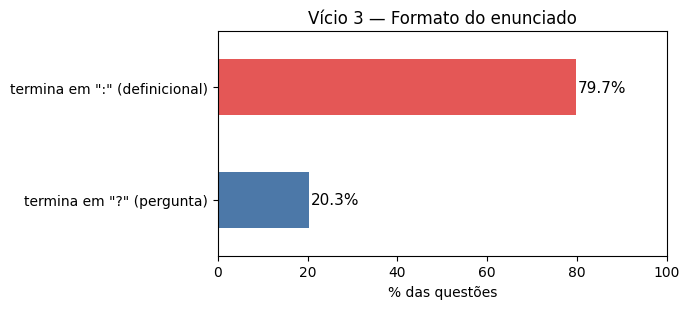

Exemplos de enunciados definicionais:
  • O indicador OEE (Overall Equipment Effectiveness) avalia:
  • Um FPSO que opera com 95% de uptime tem:
  • O KPI que mede o volume produzido comparado ao potencial máximo é:
  • A produção diferida (deferred production) se refere a:
  • A medição de vazão instantânea de óleo permite:


In [4]:
def stem_style(q):
    s = q["question"].strip()
    if s.endswith(":"): return 'termina em ":" (definicional)'
    if s.endswith("?"): return 'termina em "?" (pergunta)'
    return "outro"

styles = pd.Series([stem_style(q) for q in questions]).value_counts() / N * 100

fig, ax = plt.subplots(figsize=(7, 3.2))
styles.plot(kind="barh", ax=ax, color=["#e45756", "#4c78a8", "#9ecae1"][:len(styles)])
for i, v in enumerate(styles.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=11)
ax.set_xlim(0, 100)
ax.set_xlabel("% das questões")
ax.set_title("Vício 3 — Formato do enunciado")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

exemplos = [q["question"] for q in questions if q["question"].strip().endswith(":")][:5]
print("Exemplos de enunciados definicionais:")
for e in exemplos: print("  •", e)

## Vício 4 — Distratores-lixo (curtos e implausíveis)

Muitos distratores têm **1–2 palavras** e são tão fora de contexto (*"Vagas de hotel"*,
*"Horário do dia"*) que podem ser eliminados por qualquer leigo. O gráfico compara a
distribuição do tamanho (em palavras) das **corretas** vs. **distratores**.

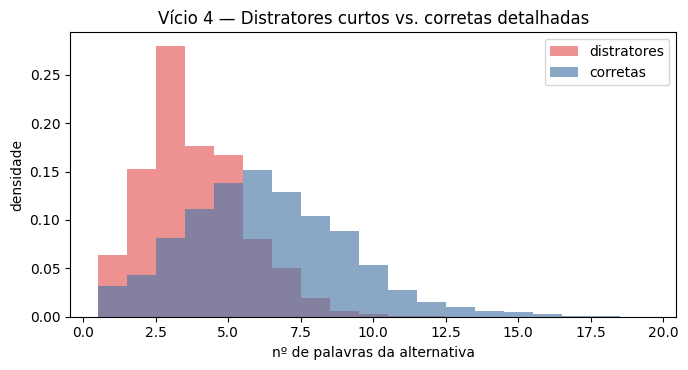

38.6% das questões têm pelo menos um distrator com ≤2 palavras.
Mediana de palavras — corretas: 6 | distratores: 4


In [5]:
all_dis_w = np.array([n_words(d) for q in questions for d in distractors(q)])

fig, ax = plt.subplots(figsize=(7, 3.8))
bins = np.arange(0.5, 20.5, 1)
ax.hist(np.clip(all_dis_w, 0, 20), bins=bins, alpha=0.65, density=True,
        label="distratores", color="#e45756")
ax.hist(np.clip(cor_w, 0, 20), bins=bins, alpha=0.65, density=True,
        label="corretas", color="#4c78a8")
ax.set_xlabel("nº de palavras da alternativa")
ax.set_ylabel("densidade")
ax.set_title("Vício 4 — Distratores curtos vs. corretas detalhadas")
ax.legend()
plt.tight_layout(); plt.show()

has_short = np.mean([any(n_words(d) <= 2 for d in distractors(q)) for q in questions])
print(f"{has_short:.1%} das questões têm pelo menos um distrator com ≤2 palavras.")
print(f"Mediana de palavras — corretas: {np.median(cor_w):.0f} | distratores: {np.median(all_dis_w):.0f}")

## Consequência: dá para acertar **sem saber nada de óleo e gás**

Testamos estratégias de **chute cego** — que não usam nenhum conhecimento do domínio,
só exploram os vícios acima. Se o dataset fosse limpo, todas ficariam perto de **25%**.

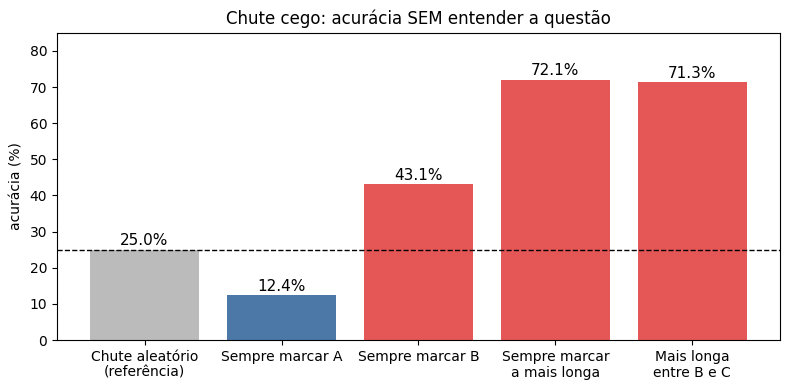

Um leigo que sempre marca a alternativa mais longa acerta 72% — quase 3x o acaso.


In [6]:
strategies = {
    "Chute aleatório\n(referência)": 25.0,
    "Sempre marcar A": key_counts["A"] / N * 100,
    "Sempre marcar B": key_counts["B"] / N * 100,
    "Sempre marcar\na mais longa": np.mean([
        max(range(4), key=lambda i: n_words(q["choices"]["text"][i])) == correct_index(q)
        for q in questions]) * 100,
    "Mais longa\nentre B e C": np.mean([
        max([1, 2], key=lambda i: n_words(q["choices"]["text"][i])) == correct_index(q)
        for q in questions]) * 100,
}
s = pd.Series(strategies)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#bbbbbb"] + ["#e45756" if v > 30 else "#4c78a8" for v in s.values[1:]]
bars = ax.bar(s.index, s.values, color=colors)
ax.axhline(25, color="k", ls="--", lw=1)
for b, v in zip(bars, s.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1.2, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, 85)
ax.set_ylabel("acurácia (%)")
ax.set_title("Chute cego: acurácia SEM entender a questão")
plt.tight_layout(); plt.show()

acc_longa = s.iloc[3]
print(f"Um leigo que sempre marca a alternativa mais longa acerta {acc_longa:.0f}% — quase 3x o acaso.")

## Questões reais: por que o chute funciona

Abaixo, questões do dataset em que os quatro vícios aparecem juntos: enunciado
definicional, correta em B/C, correta bem mais longa e distratores absurdos.
Repare que **qualquer pessoa** eliminaria *"Vagas de hotel"* ou *"Horário do dia"*
sem saber o que é um FPSO.

In [7]:
def score_viciada(q):
    """Quanto maior, mais 'chutável' a questão."""
    cw  = n_words(correct_text(q))
    dws = [n_words(d) for d in distractors(q)]
    s  = 2.0 * (cw / max(np.mean(dws), 1e-6))            # correta muito mais longa
    s += 1.5 * sum(1 for d in dws if d <= 2)             # distratores-lixo
    s += 1.0 * q["question"].strip().endswith(":")       # definicional
    s += 1.0 * (q["answerKey"] in "BC")                  # posição viciada
    return s

ranked = sorted(questions, key=score_viciada, reverse=True)

def mostra(q):
    ci = correct_index(q)
    print(f"[id {q['id']} | {q['subject']}]  gabarito: {q['answerKey']}")
    print(q["question"])
    for i, (lab, txt) in enumerate(zip(q["choices"]["label"], q["choices"]["text"])):
        marca = " ◀ CORRETA (e a mais longa)" if i == ci else ""
        print(f"   {lab}) {txt}  [{n_words(txt)} palavras]{marca}")
    print("-" * 90)

for q in ranked[:4]:
    mostra(q)

[id 1623 | Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos]  gabarito: D
A ferramenta normalmente utilizada para avaliar riscos de SIMOPS é:
   A) PAE  [1 palavras]
   B) HAZID  [1 palavras]
   C) PTW  [1 palavras]
   D) JSA ou AST (Análise de Segurança da Tarefa)  [8 palavras] ◀ CORRETA (e a mais longa)
------------------------------------------------------------------------------------------
[id 613 | Produção e Processo (Medição Fiscal e Sistema de Alívio)]  gabarito: B
Qual dos seguintes produtos químicos é mais utilizado para controle de corrosão na água produzida antes da descarga?
   A) Biocida  [1 palavras]
   B) Inibidor de corrosão à base de amina  [7 palavras] ◀ CORRETA (e a mais longa)
   C) Floculante  [1 palavras]
   D) Desemulsificante  [1 palavras]
------------------------------------------------------------------------------------------
[id 47 | Gestão do Desempenho]  gabarito: C
O KPI que mede a quantidade de óleo produzido por dia é conhecido co

### Exemplos escolhidos a dedo

Duas questões que ilustram o problema com clareza:

**id 22** — *"O planejamento de manutenção deve considerar:"*
> A) Vagas de hotel *(2 palavras)* · **B) Condições climáticas, peças, mão de obra e janela de oportunidade** *(10 palavras)* · C) Tabelas fiscais *(2)* · D) Atividades do RH *(3)*

Não é preciso saber nada de manutenção offshore: B é a única alternativa longa,
detalhada e que "soa profissional" — as outras três são absurdas.

**id 6** — *"A eficiência operacional de um FPSO é impactada por:"*
> A) Ventos · B) Custos fixos · **C) Gargalos nos sistemas de processo** · D) Horário do dia

Mesmo sem saber o que é FPSO, "gargalos nos sistemas de processo" é a única resposta
com jeito de resposta; "horário do dia" é eliminável na hora.

## Conclusão

Os quatro vícios se combinam para tornar o dataset **exploitável sem conhecimento do
domínio**: chute cego pela alternativa mais longa acerta ~72%, e sempre marcar B
acerta ~43%. Qualquer avaliação de agentes feita sobre a base crua superestimaria a
capacidade dos modelos. É exatamente isso que o pipeline de refino
(`QA_refinement_pipeline.ipynb`) ataca: reescrever as questões mais viciadas com
enunciados de cenário, alternativas de tamanho equilibrado, distratores plausíveis e
gabarito distribuído.